# Filtros de acentuado

1. Obtenga versiones mejoradas de diferentes im agenes mediante el filtrado por
m ́ascara difusa. Implemente el c ́alculo como
g(x,y) = f(x,y) −PB(f(x,y))
2. Una forma de enfatizar las altas frecuencias sin perder los detalles de bajas
frecuencias es el filtrado de alta potencia. Implemente este procesamiento
como la operaci ́on aritm ́etica:
g(x,y) = Af(x,y) −PB(f(x,y)), con A ≥1.
* Investigue y pruebe m ́etodos alternativos de c ́alculo en una pasada.

In [1]:
# Configuración Inicial e Importaciones
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider
import ipywidgets as widgets


In [2]:
def comparar_imagenes(img_1, img_2, titulo_original="Original", titulo_filtrada="Filtrada"):
    fig, axs = plt.subplots(1,2, figsize=(10,5))
    
    # Original
    axs[0].imshow(img_1, cmap="gray")
    axs[0].set_title(titulo_original)
    axs[0].axis("off")
    
    # Máscara difusa - Fijar vmin=0 para que el fondo (0) sea NEGRO
    # Los valores negativos se verán negros también
    axs[1].imshow(img_2, cmap="gray", vmin=0, vmax=255)
    axs[1].set_title(titulo_filtrada)
    axs[1].axis("off")
    
    plt.tight_layout()
    plt.show()

def mascara_difusa_interact(img, kernel_size):
    img_float = img.astype(np.float32)
    

    mask = np.ones((kernel_size, kernel_size), np.float32) / (kernel_size**2)
    img_pb = cv2.filter2D(img_float, -1, mask)  # Usar img_float
    

    hp = img_float - img_pb
    mascara_norm = cv2.normalize(hp, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)


    
    comparar_imagenes(
        img,
        mascara_norm,
        "Original",
        f"Máscara Difusa (Kernel {kernel_size}x{kernel_size})"
    )


def highboost_interact(img, kernel_size, A):

    img_float = img.astype(np.float32)

        # filtro pasa-bajos
    mask = np.ones((kernel_size, kernel_size), np.float32) / (kernel_size**2)
    img_pb = cv2.filter2D(img_float, -1, mask)

        # high-boost
    highboost = A * img_float - img_pb

        # clipping
    highboost = np.clip(highboost, 0, 255).astype(np.uint8)

    comparar_imagenes(
        img,
        highboost,
        "Original",
        f"HighBoost A={A:.1f} Kernel={kernel_size}x{kernel_size}"
    )

## ejercicio 1

La mascara difusa es la diferencia entre la imagen original y su version pasabajos suavizada $$G(x,y) = f(x,y) - Pb\left(F(x,y)\right)$$

Puede ocurrir que en pixeles el pasabajo tenga mas intensidad que su version origianl, dando numeros negativos. Para ello entonces necesitamos desplazar nuestro cero.




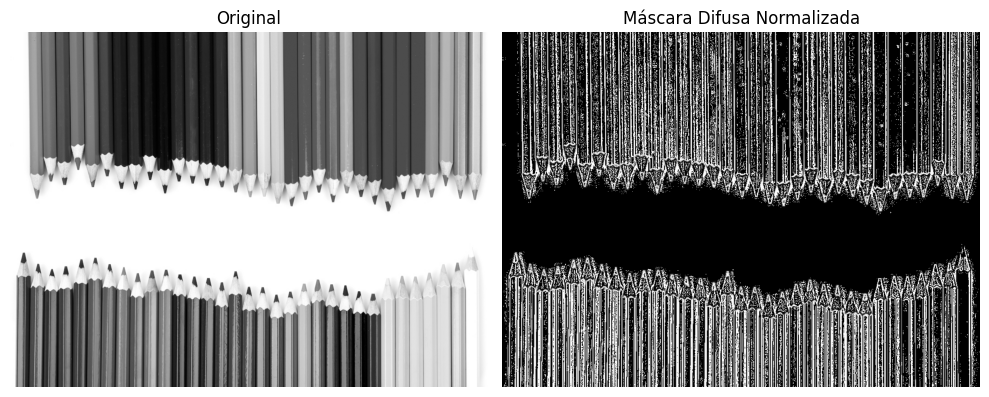

In [3]:
img = cv2.imread("../Imagenes_cursado/lapices02.jpg", cv2.IMREAD_GRAYSCALE)

#primero construimos la mascara pasabajo, ejemplo promedio

mask_7x7 = np.ones((5,5), np.float32) / 25
img_pb = cv2.filter2D(img, -1, mask_7x7)

#luego hacemos la diferencia entre ambas


mascara_difusa = img - img_pb

mascara_norm = cv2.normalize(mascara_difusa, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)

# Comparar
comparar_imagenes(img.astype(np.uint8), mascara_norm, "Original", "Máscara Difusa Normalizada")


Al restar la versión suavizada, nos quedamos con los detalles (cambios altos frecuencia, cambios bruscos)
- Donde no hubo cambio es zona homogenea, intensidades similares, da resultado cero (negro)
- Donde si hubo cambios en la frecuencia, es porque el suavizado afecto el pixel y se ve.

In [4]:
interact(
    lambda kernel_size: mascara_difusa_interact(img, kernel_size),
    
    kernel_size=IntSlider(
        value=5,
        min=3,
        max=15,
        step=2,
        description="Kernel"
    ),
    
    k=FloatSlider(
        value=1.0,
        min=0.1,
        max=5.0,
        step=0.1,
        description="mascara"
    )
)

interactive(children=(IntSlider(value=5, description='Kernel', max=15, min=3, step=2), Output()), _dom_classes…

<function __main__.<lambda>(kernel_size)>

se ve gris por el reescalado

## ejercicio 2

Filtrado ded alta potencia

Es la diferencia entre una version amplificada de la funcion original y una version suavizada

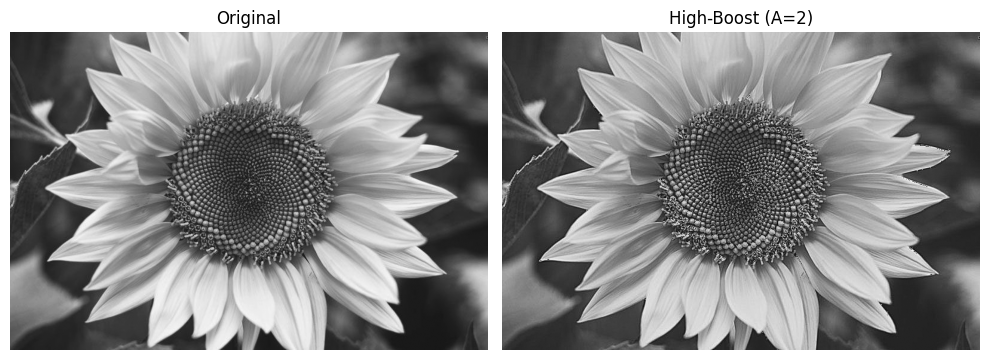

In [5]:
img = cv2.imread("../Imagenes_cursado/flores02.jpg", cv2.IMREAD_GRAYSCALE)

img_pb = cv2.filter2D(img, -1, mask_7x7)

A= 2

High_boost = A * img - img_pb
comparar_imagenes(img, High_boost, "Original", f"High-Boost (A={A})")


In [6]:
interact(
    lambda kernel_size, A: highboost_interact(img, kernel_size, A),

    kernel_size=IntSlider(
        value=5,
        min=3,
        max=15,
        step=2,
        description="Kernel"
    ),

    A=FloatSlider(
        value=1.0,
        min=0.1,
        max=5.0,
        step=0.1,
        description="A"
    )
)

interactive(children=(IntSlider(value=5, description='Kernel', max=15, min=3, step=2), FloatSlider(value=1.0, …

<function __main__.<lambda>(kernel_size, A)>